# NB10 — Revised Publication Figures

Private editorial/review notebook.

**No model retraining.** It regenerates the manuscript figures using frozen NB01–NB08 outputs plus descriptive NB09B slopes where needed.

Revision rules implemented:

- Figure 1 completely rebuilt with uniform boxes, no overlap/cropping, consistent typography.
- Figure 2 explicitly differentiates median, mean and outliers.
- Figure 3 adds predicted-on-observed regression lines and slopes.
- Figure 4 treats Original / Reversed / Shuffled as unordered categories: **no connecting lines**; paired-inference clarification is placed in the external caption.
- Figures 4–5 use a colorblind-safe palette and redundant markers/line styles.
- Figure 6 explicitly labels the MAE definition as pooled seed-mean OOF MAE.
- All publication images have **no internal top title**.
- PNG and TIFF export at 600 dpi.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

ROOT=Path('/content/drive/MyDrive/NIR_HUEVOS_PAPER_REBUILD_2026')
NB03=ROOT/'05_RESULTS'/'NB03_CHEMOMETRIC_BASELINES'
NB04=ROOT/'05_RESULTS'/'NB04_DEEP_LEARNING_BENCHMARK'
NB06=ROOT/'05_RESULTS'/'NB06_STATISTICAL_ROBUSTNESS'
NB07=ROOT/'05_RESULTS'/'NB07_PRACTICAL_APPLICABILITY'
NB09B=ROOT/'05_RESULTS'/'NB09B_REVIEWER_ADDITIONAL_ANALYSES'

FIG_DIR=ROOT/'06_FIGURES'/'NB10_REVISED_PUBLICATION_FIGURES'
TAB_DIR=ROOT/'07_TABLES'/'NB10_REVISED_PUBLICATION_FIGURES'
FIG_DIR.mkdir(parents=True,exist_ok=True)
TAB_DIR.mkdir(parents=True,exist_ok=True)

RUN_REVISION='NB10_v1_review_figure_revision'

Mounted at /content/drive


In [ ]:
# 1. Publication style
font_candidates=['Palatino Linotype','Palatino','Book Antiqua','URW Palladio L','DejaVu Serif']
available={f.name for f in font_manager.fontManager.ttflist}
FONT=next((f for f in font_candidates if f in available),'DejaVu Serif')

plt.rcParams.update({
    'font.family':FONT,
    'font.size':10,
    'axes.labelsize':10,
    'xtick.labelsize':9,
    'ytick.labelsize':9,
    'legend.fontsize':9,
    'figure.dpi':150,
    'savefig.dpi':600,
    'savefig.bbox':'tight',
    'savefig.facecolor':'white',
    'axes.facecolor':'white',
})

# Okabe–Ito colorblind-safe palette
OI = {
    'blue':'#0072B2',
    'orange':'#E69F00',
    'green':'#009E73',
    'vermillion':'#D55E00',
    'purple':'#CC79A7',
    'sky':'#56B4E9',
    'yellow':'#F0E442',
    'black':'#000000'
}
print('Font used:',FONT)

Font used: DejaVu Serif


In [ ]:
# 2. Helpers
def save_figure(fig, stem):
    png=FIG_DIR/f'{stem}.png'
    tif=FIG_DIR/f'{stem}.tiff'
    fig.savefig(png,dpi=600,bbox_inches='tight',facecolor='white')
    fig.savefig(tif,dpi=600,bbox_inches='tight',facecolor='white')
    print('saved',png.name,tif.name)

def load_oof():
    a=pd.read_csv(NB03/'NB03_oof_predictions.csv')
    a=a[a.model.isin(['PLSR','SVR'])][['sample','storage_days','outer_fold','model','y_pred']]
    b=pd.read_csv(NB04/'NB04_oof_predictions_seedmean.csv')
    if 'y_pred_seedmean' in b.columns and 'y_pred' not in b.columns:
        b=b.rename(columns={'y_pred_seedmean':'y_pred'})
    b=b[b.model.isin(['ANN','SimpleRNN','LSTM','BiLSTM'])][['sample','storage_days','outer_fold','model','y_pred']]
    return pd.concat([a,b],ignore_index=True)

## Figure 1 — leakage-safe analytical workflow

saved Figure_1_REVISED_Leakage_Safe_Workflow.png Figure_1_REVISED_Leakage_Safe_Workflow.tiff


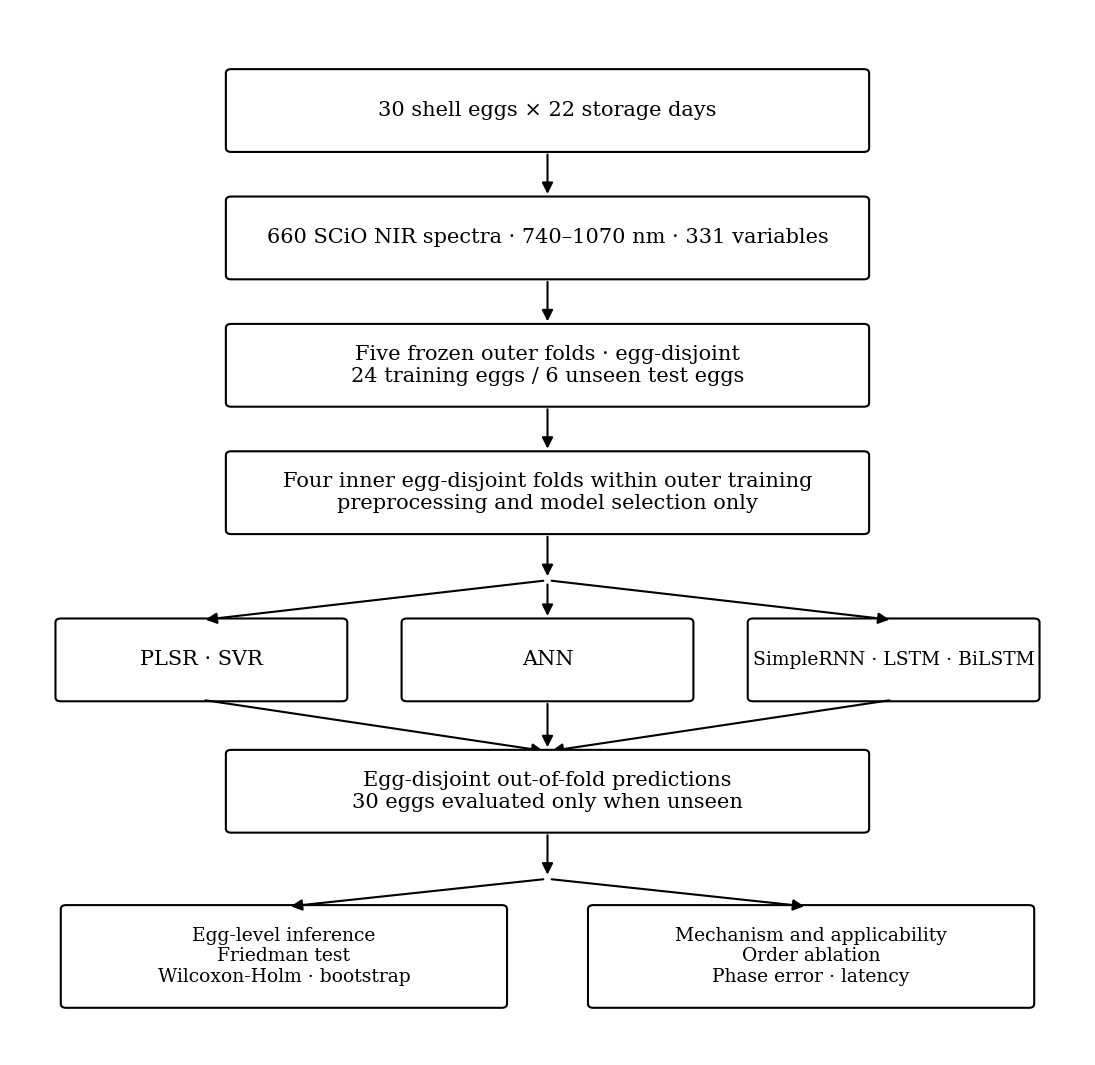

In [13]:
# 3. Figure 1 — rebuilt from scratch; corrected lower boxes to avoid overflow
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(7.4, 7.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 13)
ax.axis('off')

box_kw = dict(
    boxstyle='round,pad=0.02,rounding_size=0.05',
    linewidth=1.0,
    edgecolor='black',
    facecolor='white'
)

def box(x, y, w, h, text, fontsize=10):
    p = FancyBboxPatch((x, y), w, h, **box_kw)
    ax.add_patch(p)
    ax.text(
        x + w/2, y + h/2, text,
        ha='center', va='center',
        fontsize=fontsize,
        wrap=True
    )
    return p

def arrow(x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle='-|>',
            mutation_scale=11,
            linewidth=1.0,
            color='black'
        )
    )

# Top workflow
box(2.0, 11.3, 6.0, 1.0, '30 shell eggs × 22 storage days')
arrow(5, 11.3, 5, 10.7)

box(2.0, 9.7, 6.0, 1.0, '660 SCiO NIR spectra · 740–1070 nm · 331 variables')
arrow(5, 9.7, 5, 9.1)

box(2.0, 8.1, 6.0, 1.0, 'Five frozen outer folds · egg-disjoint\n24 training eggs / 6 unseen test eggs')
arrow(5, 8.1, 5, 7.5)

box(2.0, 6.5, 6.0, 1.0, 'Four inner egg-disjoint folds within outer training\npreprocessing and model selection only')
arrow(5, 6.5, 5, 5.9)

# Model families
box(0.4, 4.4, 2.7, 1.0, 'PLSR · SVR')
box(3.65, 4.4, 2.7, 1.0, 'ANN')
box(6.9, 4.4, 2.7, 1.0, 'SimpleRNN · LSTM · BiLSTM', fontsize=9)

arrow(5, 5.9, 1.75, 5.4)
arrow(5, 5.9, 5.0, 5.4)
arrow(5, 5.9, 8.25, 5.4)

arrow(1.75, 4.4, 5, 3.75)
arrow(5.0, 4.4, 5, 3.75)
arrow(8.25, 4.4, 5, 3.75)

# OOF predictions
box(2.0, 2.75, 6.0, 1.0, 'Egg-disjoint out-of-fold predictions\n30 eggs evaluated only when unseen')
arrow(5, 2.75, 5, 2.15)

# Bottom boxes corrected
box(
    0.45, 0.55, 4.15, 1.25,
    'Egg-level inference\nFriedman test\nWilcoxon-Holm · bootstrap',
    fontsize=9
)

box(
    5.40, 0.55, 4.15, 1.25,
    'Mechanism and applicability\nOrder ablation\nPhase error · latency',
    fontsize=9
)

arrow(5, 2.15, 2.55, 1.80)
arrow(5, 2.15, 7.45, 1.80)

fig.tight_layout()
save_figure(fig, 'Figure_1_REVISED_Leakage_Safe_Workflow')
plt.show()

## Figure 2 — per-egg MAE with unambiguous mean/median/outliers

/tmp/ipykernel_5418/730688848.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp=ax.boxplot(


saved Figure_2_REVISED_Per_Egg_MAE.png Figure_2_REVISED_Per_Egg_MAE.tiff


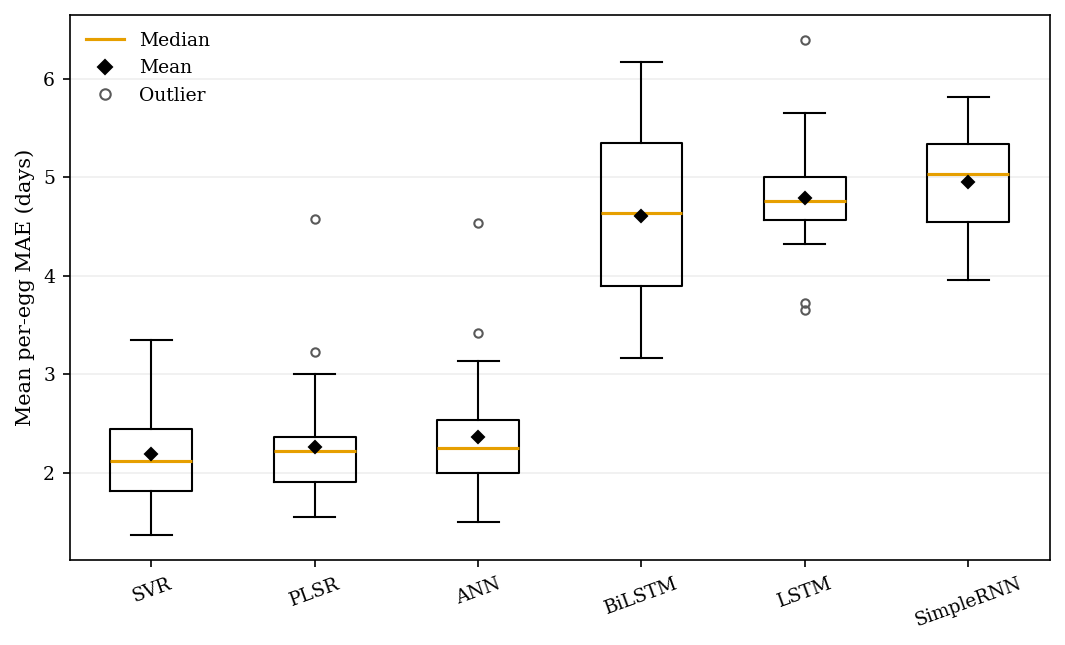

In [ ]:
# 4. Figure 2
primary=pd.read_csv(NB06/'NB06_primary_per_egg_MAE_wide.csv')
models=['SVR','PLSR','ANN','BiLSTM','LSTM','SimpleRNN']

# Handle either wide columns exactly named by model or long-ish fallback.
data=[]
for m in models:
    if m in primary.columns:
        data.append(primary[m].dropna().to_numpy())
    else:
        raise ValueError(f'Missing {m} in {primary.columns.tolist()}')

fig,ax=plt.subplots(figsize=(7.2,4.4))
bp=ax.boxplot(
    data,labels=models,patch_artist=False,showmeans=True,
    meanprops=dict(marker='D',markerfacecolor=OI['black'],markeredgecolor=OI['black'],markersize=4),
    medianprops=dict(linewidth=1.5,color=OI['orange']),
    flierprops=dict(marker='o',markerfacecolor='none',markeredgecolor='0.35',markersize=4,linestyle='none')
)
ax.set_ylabel('Mean per-egg MAE (days)')
ax.tick_params(axis='x',rotation=20)
ax.grid(axis='y',alpha=0.2)

# small explanatory legend
from matplotlib.lines import Line2D
legend=[
    Line2D([0],[0],color=OI['orange'],lw=1.5,label='Median'),
    Line2D([0],[0],marker='D',color='none',markerfacecolor=OI['black'],markeredgecolor=OI['black'],
           markersize=5,label='Mean'),
    Line2D([0],[0],marker='o',color='none',markerfacecolor='none',markeredgecolor='0.35',
           markersize=5,label='Outlier')
]
ax.legend(handles=legend,loc='upper left',frameon=False)
fig.tight_layout()
save_figure(fig,'Figure_2_REVISED_Per_Egg_MAE')
plt.show()

## Figure 3 — observed versus OOF predicted with attenuation slopes

saved Figure_3_REVISED_Observed_vs_Predicted.png Figure_3_REVISED_Observed_vs_Predicted.tiff


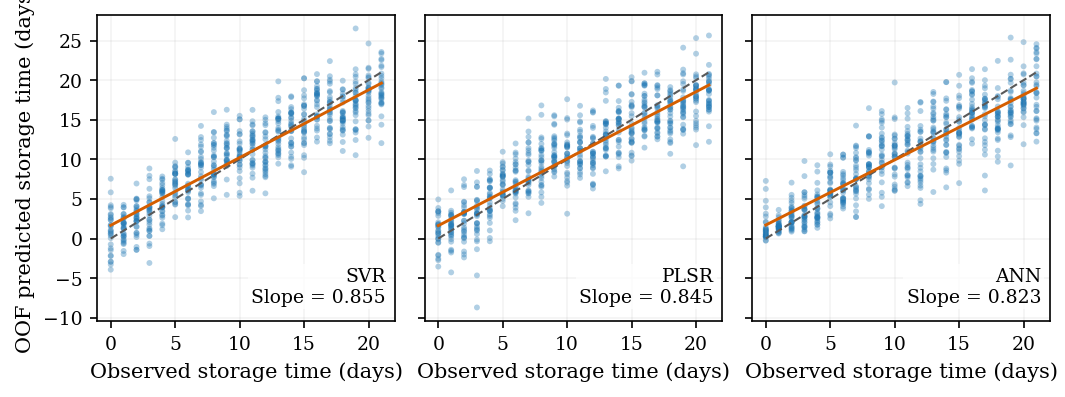

In [ ]:
# 5. Figure 3
from scipy.stats import linregress
oof=load_oof()
top=['SVR','PLSR','ANN']

fig,axes=plt.subplots(1,3,figsize=(7.2,2.75),sharex=True,sharey=True)

for ax,m in zip(axes,top):
    g=oof[oof.model==m]
    ax.scatter(g.storage_days,g.y_pred,s=8,alpha=0.35,edgecolors='none')
    ax.plot([0,21],[0,21],linestyle='--',linewidth=1,color='0.35')
    lr=linregress(g.storage_days,g.y_pred)
    xx=np.linspace(0,21,100)
    ax.plot(xx,lr.intercept+lr.slope*xx,linewidth=1.4,color=OI['vermillion'])
    ax.text(0.97,0.05,f'{m}\nSlope = {lr.slope:.3f}',
            transform=ax.transAxes,ha='right',va='bottom',fontsize=9,
            bbox=dict(facecolor='white',edgecolor='none',alpha=0.8,pad=1.5))
    ax.set_xlabel('Observed storage time (days)')
    ax.grid(alpha=0.15)

axes[0].set_ylabel('OOF predicted storage time (days)')
fig.tight_layout()
save_figure(fig,'Figure_3_REVISED_Observed_vs_Predicted')
plt.show()

## Figure 4 — unordered wavelength-order categories; no connecting lines

saved Figure_4_REVISED_Wavelength_Order_Ablation.png Figure_4_REVISED_Wavelength_Order_Ablation.tiff


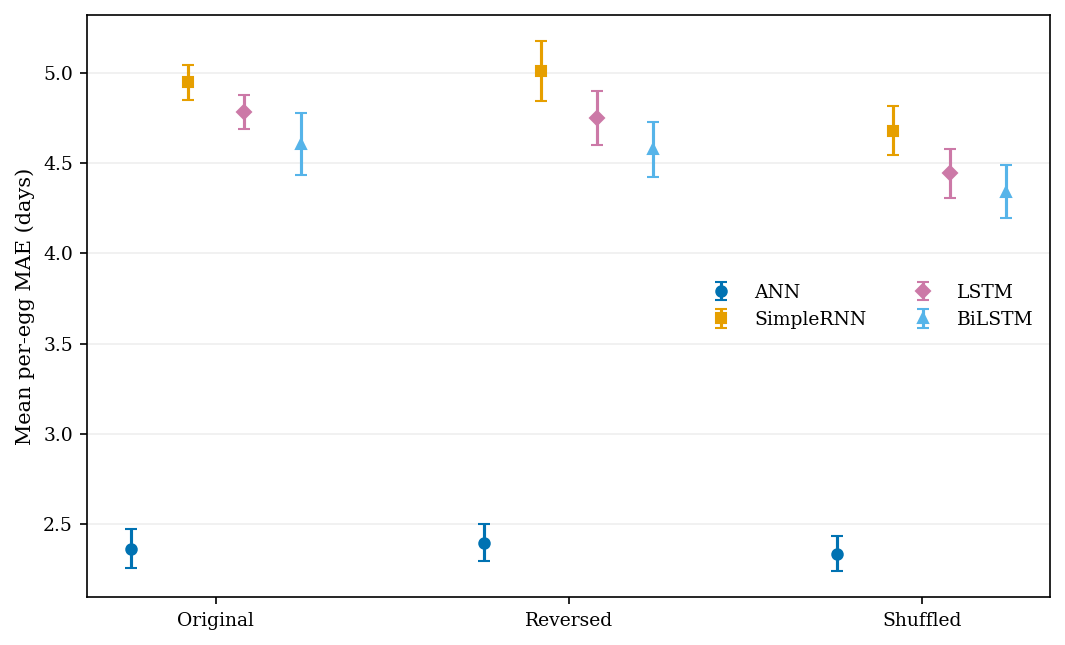

In [ ]:
# 6. Figure 4
order=pd.read_csv(NB06/'NB06_order_per_egg_MAE_primary.csv')

# Expected columns: model, order_condition, sample, MAE_days (or close variants)
rename={}
for c in order.columns:
    lc=c.lower()
    if lc in {'condition','order'}: rename[c]='order_condition'
    if lc in {'mae','mae_days'}: rename[c]='MAE_days'
order=order.rename(columns=rename)

conditions=['original','reversed','shuffled']
models=['ANN','SimpleRNN','LSTM','BiLSTM']
markers={'ANN':'o','SimpleRNN':'s','LSTM':'D','BiLSTM':'^'}
colors={'ANN':OI['blue'],'SimpleRNN':OI['orange'],'LSTM':OI['purple'],'BiLSTM':OI['sky']}

fig,ax=plt.subplots(figsize=(7.2,4.4))
x=np.arange(len(conditions))
offsets=np.linspace(-0.24,0.24,len(models))

summary_rows=[]
for off,m in zip(offsets,models):
    means=[]; ses=[]
    for cond in conditions:
        g=order[(order.model==m)&(order.order_condition.str.lower()==cond)]
        v=g['MAE_days'].to_numpy(float)
        means.append(v.mean())
        ses.append(v.std(ddof=1)/np.sqrt(len(v)))
        summary_rows.append({'model':m,'condition':cond,'mean_MAE':v.mean(),'marginal_SE':ses[-1]})
    ax.errorbar(
        x+off,means,yerr=ses,fmt=markers[m],linestyle='none',
        capsize=3,markersize=5,label=m,color=colors[m]
    )

ax.set_xticks(x, ['Original','Reversed','Shuffled'])
ax.set_ylabel('Mean per-egg MAE (days)')
ax.grid(axis='y',alpha=0.2)
ax.legend(frameon=False,ncol=2)
pd.DataFrame(summary_rows).to_csv(TAB_DIR/'Figure_4_marginal_summary.csv',index=False)
fig.tight_layout()
save_figure(fig,'Figure_4_REVISED_Wavelength_Order_Ablation')
plt.show()

## Figure 5 — storage-day MAE and bias using colorblind-safe + redundant line styles

saved Figure_5_REVISED_Error_Bias_Storage_Day.png Figure_5_REVISED_Error_Bias_Storage_Day.tiff


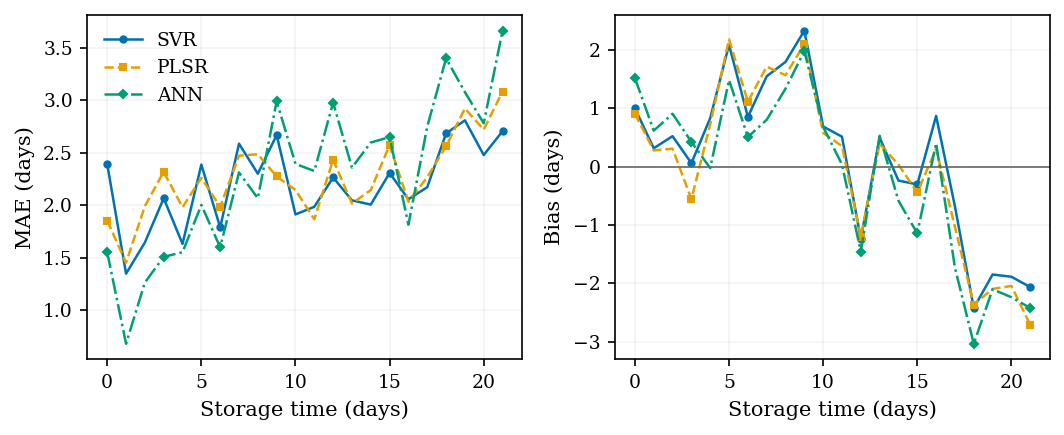

In [ ]:
# 7. Figure 5
day=pd.read_csv(NB07/'NB07_metrics_by_storage_day.csv')
if 'storage_day' in day.columns and 'storage_days' not in day.columns:
    day=day.rename(columns={'storage_day':'storage_days'})

top=['SVR','PLSR','ANN']
colors={'SVR':OI['blue'],'PLSR':OI['orange'],'ANN':OI['green']}
styles={'SVR':'-','PLSR':'--','ANN':'-.'}
markers={'SVR':'o','PLSR':'s','ANN':'D'}

fig,axes=plt.subplots(1,2,figsize=(7.2,3.0),sharex=True)
for m in top:
    g=day[day.model==m].sort_values('storage_days')
    axes[0].plot(g.storage_days,g.MAE_days,label=m,color=colors[m],linestyle=styles[m],
                 marker=markers[m],markersize=3,markevery=3,linewidth=1.2)
    axes[1].plot(g.storage_days,g.bias_days,label=m,color=colors[m],linestyle=styles[m],
                 marker=markers[m],markersize=3,markevery=3,linewidth=1.2)

axes[0].set_ylabel('MAE (days)')
axes[1].set_ylabel('Bias (days)')
for ax in axes:
    ax.set_xlabel('Storage time (days)')
    ax.grid(alpha=0.15)
axes[1].axhline(0,color='0.4',linewidth=0.8)
axes[0].legend(frameon=False)
fig.tight_layout()
save_figure(fig,'Figure_5_REVISED_Error_Bias_Storage_Day')
plt.show()

## Figure 6 — accuracy-latency plane with explicit pooled OOF MAE definition

saved Figure_6_REVISED_Accuracy_Latency.png Figure_6_REVISED_Accuracy_Latency.tiff


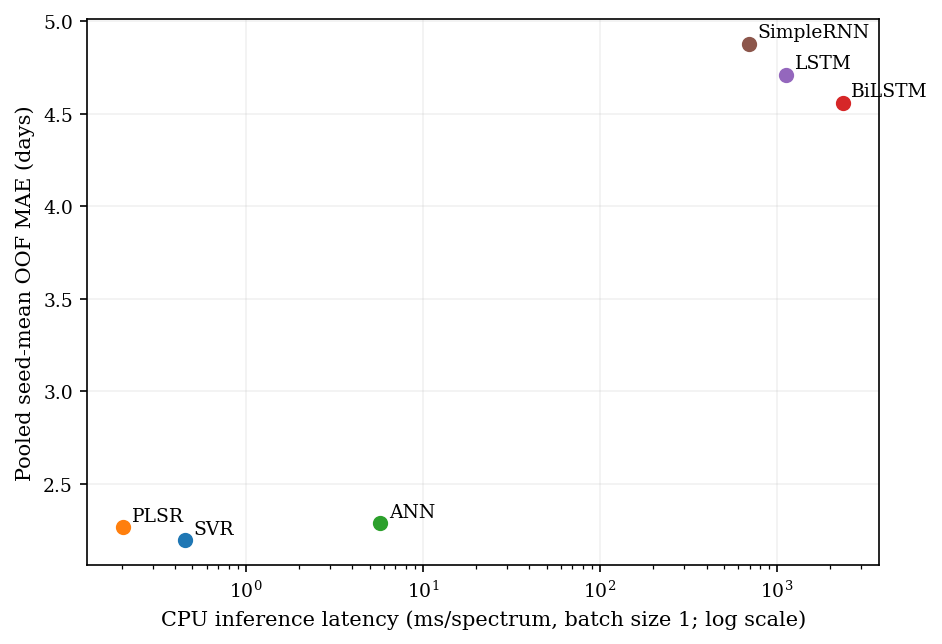

In [ ]:
# 8. Figure 6
perf=pd.read_csv(NB07/'NB07_integrated_practical_applicability_table.csv')

# Normalize columns using substring matching
def find_col(df, needles):
    for c in df.columns:
        lc=c.lower()
        if all(n.lower() in lc for n in needles):
            return c
    return None

model_col='model' if 'model' in perf.columns else 'Model'
mae_col=find_col(perf,['mae'])
lat_col=find_col(perf,['median','ms','spectrum']) or find_col(perf,['latency','ms'])

if lat_col is None:
    lat=pd.read_csv(NB07/'NB07_CPU_inference_latency.csv')
    lat=lat[lat['batch_size']==1].copy()
    lat_col='end_to_end_median_ms_per_spectrum'
    perf=perf.merge(lat[['model',lat_col]],on='model',how='left')
    model_col='model'

fig,ax=plt.subplots(figsize=(6.4,4.4))
for _,r in perf.iterrows():
    m=str(r[model_col])
    if m=='DummyMean': continue
    ax.scatter(float(r[lat_col]),float(r[mae_col]),s=40)
    ax.annotate(m,(float(r[lat_col]),float(r[mae_col])),xytext=(4,3),
                textcoords='offset points',fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('CPU inference latency (ms/spectrum, batch size 1; log scale)')
ax.set_ylabel('Pooled seed-mean OOF MAE (days)')
ax.grid(alpha=0.18)
fig.tight_layout()
save_figure(fig,'Figure_6_REVISED_Accuracy_Latency')
plt.show()

In [ ]:
# 9. External captions with reviewer clarifications
captions = {
'Figure 1': (
    'Leakage-safe analytical workflow. The egg is the independent biological unit. '
    'All preprocessing, model selection, and epoch selection are restricted to outer-training eggs; '
    'outer-test eggs contribute only out-of-fold predictions.'
),
'Figure 2': (
    'Distribution of the inferential mean per-egg MAE across 30 eggs. The orange line denotes the median, '
    'the filled diamond denotes the mean, and open circles denote boxplot outliers. For deep-learning '
    'models, the inferential per-egg MAE is calculated within each seed and then averaged across seeds; '
    'therefore these values differ slightly from pooled seed-mean OOF MAE used in descriptive performance figures.'
),
'Figure 3': (
    'Observed versus egg-disjoint OOF predicted storage time for SVR, PLSR, and ANN. The dashed line is identity; '
    'the solid regression line is predicted storage time regressed on observed storage time. Slopes below one '
    'quantify compression of predictions toward the center of the experimental range.'
),
'Figure 4': (
    'Wavelength-order ablation. Original, reversed, and shuffled are unordered experimental conditions and are '
    'therefore shown without connecting lines. Error bars are marginal standard errors across eggs and are not '
    'the basis of significance testing. Inferential comparisons use paired egg-level differences with '
    'Wilcoxon tests and Holm correction.'
),
'Figure 5': (
    'MAE and bias across storage day for the three competitive models using frozen egg-disjoint OOF predictions. '
    'Negative bias at later storage days indicates systematic underestimation.'
),
'Figure 6': (
    'Accuracy–latency reference plane. The vertical metric is pooled OOF MAE computed from seed-mean predictions '
    'for deep-learning models; it is descriptive and differs from the inferential per-egg seedwise MAE in Figure 2. '
    'CPU latency is hardware- and implementation-specific and should not be interpreted as SCiO or embedded-device latency.'
)
}
(TAB_DIR/'NB10_REVISED_FIGURE_CAPTIONS.json').write_text(json.dumps(captions,indent=2),encoding='utf-8')
for k,v in captions.items():
    print(k+':',v,'\n')

Figure 1: Leakage-safe analytical workflow. The egg is the independent biological unit. All preprocessing, model selection, and epoch selection are restricted to outer-training eggs; outer-test eggs contribute only out-of-fold predictions. 

Figure 2: Distribution of the inferential mean per-egg MAE across 30 eggs. The orange line denotes the median, the filled diamond denotes the mean, and open circles denote boxplot outliers. For deep-learning models, the inferential per-egg MAE is calculated within each seed and then averaged across seeds; therefore these values differ slightly from pooled seed-mean OOF MAE used in descriptive performance figures. 

Figure 3: Observed versus egg-disjoint OOF predicted storage time for SVR, PLSR, and ANN. The dashed line is identity; the solid regression line is predicted storage time regressed on observed storage time. Slopes below one quantify compression of predictions toward the center of the experimental range. 

Figure 4: Wavelength-order ablat

In [ ]:
# 10. Final guards
import inspect
# This notebook intentionally uses no plt.title / set_title / suptitle.
print('Figure directory:',FIG_DIR)
print('Table/caption directory:',TAB_DIR)
print('NB10 COMPLETED')

Figure directory: /content/drive/MyDrive/NIR_HUEVOS_PAPER_REBUILD_2026/06_FIGURES/NB10_REVISED_PUBLICATION_FIGURES
Table/caption directory: /content/drive/MyDrive/NIR_HUEVOS_PAPER_REBUILD_2026/07_TABLES/NB10_REVISED_PUBLICATION_FIGURES
NB10 COMPLETED


## Download package
This final cell compresses all revised publication figures, tables, and caption files into a single ZIP for external review.

In [14]:
# 11. Package and download all NB10 publication outputs
from pathlib import Path
import zipfile
from google.colab import files

ZIP_PATH = Path('/content/NB10_RESULTS_REVISED_PUBLICATION_FIGURES.zip')

with zipfile.ZipFile(ZIP_PATH, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for base_dir, prefix in [(FIG_DIR, 'FIGURES'), (TAB_DIR, 'TABLES_AND_CAPTIONS')]:
        base_dir = Path(base_dir)
        if not base_dir.exists():
            raise FileNotFoundError(f'Expected output directory not found: {base_dir}')
        for fp in sorted(base_dir.rglob('*')):
            if fp.is_file():
                arcname = Path(prefix) / fp.relative_to(base_dir)
                zf.write(fp, arcname=str(arcname))

print('✅ ZIP created:', ZIP_PATH)
print('✅ Includes all NB10 figures, tables, and caption files.')
files.download(str(ZIP_PATH))


✅ ZIP created: /content/NB10_RESULTS_REVISED_PUBLICATION_FIGURES.zip
✅ Includes all NB10 figures, tables, and caption files.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>